# Graph Convolutional Networks, from scratch

This notebook builds a 2-layer Graph Convolutional Network (GCN) using **only plain PyTorch tensor ops** for every part of the model itself: adjacency handling, neighbor aggregation, the propagation rule, and weight sharing across nodes.

The only library exception is `networkx`, used purely to *load* the graph structure (Zachary's Karate Club). Nothing about the model comes from a graph library.

**Task**: semi-supervised node classification, following Kipf & Welling (2017), *"Semi-Supervised Classification with Graph Convolutional Networks"*. We see only a handful of labeled nodes; the model has to infer the rest from graph structure plus those few labels.

**Plan for this notebook** (built up in stages, matching how we're doing this conversation):
1. Load the graph, build the raw adjacency matrix.
2. Understand why raw aggregation is a bad idea, derive the symmetric normalization $\hat{A} = D^{-1/2} (A + I) D^{-1/2}$.
3. Implement a single GCN layer as a from-scratch tensor operation.
4. Stack two layers into a full model, and reason about *why* 2 layers = a 2-hop receptive field.
5. Set up the semi-supervised label split (a handful of labeled nodes, rest unlabeled).
6. Train, watching the loss and accuracy on the *unlabeled* nodes (the real test of whether structure alone is doing the work).
7. Visualize the embeddings after layer 1 and after layer 2, to literally see the receptive field grow.
8. (Stretch) scale the same code to Cora.


In [1]:
import networkx as nx
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

print("torch:", torch.__version__)
print("networkx:", nx.__version__)


torch: 2.14.0+cu130
networkx: 3.6.1


## 1. Load the graph and build the raw adjacency matrix

Zachary's Karate Club is 34 nodes (members of a karate club), edges are observed social ties, and after a real-world split the club divided into two factions around the instructor ("Mr. Hi") and the administrator ("Officer"). `networkx` ships this dataset with that split already recorded as a node attribute, which is exactly the label we're doing semi-supervised classification against — we are *not* using networkx for anything about the model, only to fetch these 34 nodes/edges/labels.


In [2]:
# --- Load the graph structure (networkx is only used here, for I/O) ---
G = nx.karate_club_graph()
N = G.number_of_nodes()
print(f"nodes: {N}, edges: {G.number_of_edges()}")

# Ground-truth faction labels, recorded on each node as a string:
# "Mr. Hi" (the instructor's faction) or "Officer" (the administrator's faction).
# We turn this into an integer class 0/1 purely for our own bookkeeping later —
# the *model* never sees this except for the tiny labeled subset we choose.
club_to_label = {"Mr. Hi": 0, "Officer": 1}
labels = torch.tensor(
    [club_to_label[G.nodes[i]["club"]] for i in range(N)], dtype=torch.long
)
print("label counts:", torch.bincount(labels).tolist())

# --- Build the raw (unnormalized) adjacency matrix A, by hand ---
# A is an N x N matrix where A[i, j] = 1 if there's an edge between node i and j, else 0.
# This is the entire "structure" a GCN has to work with — everything downstream is
# tensor algebra on top of this matrix.
A = torch.zeros((N, N), dtype=torch.float32)
for u, v in G.edges():
    A[u, v] = 1.0
    A[v, u] = 1.0  # undirected graph -> adjacency is symmetric

print("A shape:", A.shape)
print("A is symmetric:", torch.equal(A, A.T))
print("A row sums (= node degrees), first 10 nodes:", A.sum(dim=1)[:10])


nodes: 34, edges: 78
label counts: [17, 17]
A shape: torch.Size([34, 34])
A is symmetric: True
A row sums (= node degrees), first 10 nodes: tensor([16.,  9., 10.,  6.,  3.,  4.,  4.,  4.,  5.,  2.])


## 2. Why we can't just aggregate with raw `A` — deriving the normalization

The core operation in a graph conv is: *each node's new feature = some combination of its neighbors' current features.* In matrix form, that combination step is `A @ X`, where `X` is the (N, F) matrix of node features. Let's think through what's wrong with that, one step at a time.

**Problem 1 — raw sums blow up with degree.**
`A @ X` computes, for each node `i`, the elementwise **sum** of the feature vectors of `i`'s neighbors. A node with 16 neighbors (karate club has one — the instructor) gets a sum roughly 16x larger in magnitude than a node with 1 neighbor, purely because it has more neighbors, not because its neighborhood is more "informative." Stack a few layers of this and activations explode or vanish depending on degree — this is a pure scale artifact, not signal.

**Fix attempt — row-normalize: mean instead of sum.**
Dividing each row `i` by its degree, `D^-1 A`, turns the sum into an **average**. This solves the scale-blowup problem — every node's aggregation is now a proper weighted average of its neighbors regardless of degree. But `D^-1 A` is **not symmetric** (unless the graph is regular): the "share" of neighbor `j`'s features that flows into node `i` is `1/deg(i)`, entirely determined by the *receiver's* degree, ignoring the *sender's* degree. A message from a low-degree, more "specific" neighbor gets diluted exactly as much as a message from a hub with 100 neighbors, from `i`'s point of view — but nothing accounts for how much of `j`'s "attention" `i` is actually getting.

**The fix Kipf & Welling use — symmetric normalization: $D^{-1/2} A D^{-1/2}$.**
Instead of scaling only by the receiving node's degree, scale each edge `(i, j)` by `1 / sqrt(deg(i) * deg(j))`. Concretely, entry `(i, j)` of $D^{-1/2} A D^{-1/2}$ is:
$$\hat{a}_{ij} = \frac{a_{ij}}{\sqrt{deg(i)\, deg(j)}}$$
Two things this buys us:
1. **It stays symmetric.** $D^{-1/2} A D^{-1/2}$ is a symmetric matrix whenever `A` is (undirected graph), which keeps the operator's eigenvalues real and bounded in `[-1, 1]` — this is what keeps stacked layers numerically well-behaved (no runaway scale as we go deeper), which matters a lot once we stack multiple layers.
2. **It's a fairer split of "credit."** An edge between two hub nodes gets down-weighted a lot (`1/sqrt(deg*deg)` is small); an edge between two low-degree nodes barely gets down-weighted. A hub talking to a low-degree node gets an in-between weighting. Compare to plain row-averaging, where the *only* thing that matters is the receiver's own degree — the symmetric version also accounts for how "diluted" the sender's signal already is across its own many neighbors.

**One more fix — self-loops, so a node doesn't lose itself.**
Plain `A` has zeros on the diagonal (a node isn't its own neighbor), so `A @ X` completely discards node `i`'s own current features when computing its new representation — after a couple of layers, a node's identity gets fully overwritten by an average of neighbors-of-neighbors. Kipf & Welling fix this by adding self-loops first: $\tilde{A} = A + I$. Now every node aggregates over "myself + my neighbors," which is what lets the network blend a node's own features with neighborhood information instead of throwing the former away.

Putting it together, the full propagation matrix is:
$$\hat{A} = \tilde{D}^{-1/2} \tilde{A} \tilde{D}^{-1/2}, \qquad \tilde{A} = A + I, \quad \tilde{D}_{ii} = \sum_j \tilde{A}_{ij}$$

This `$\hat{A}$` is fixed for the whole graph (doesn't depend on learned weights) — we compute it once, and every GCN layer just does `$\hat{A} @ X @ W$`.


A_hat shape: torch.Size([34, 34])
A_hat symmetric: True
A_hat row sums (no longer 1, unlike plain row-mean — that's expected):
tensor([1.8708, 1.3268, 1.2977, 1.0096, 0.8449, 0.9903, 0.9903, 0.7538, 0.7808,
        0.6435])

row-mean version symmetric: False


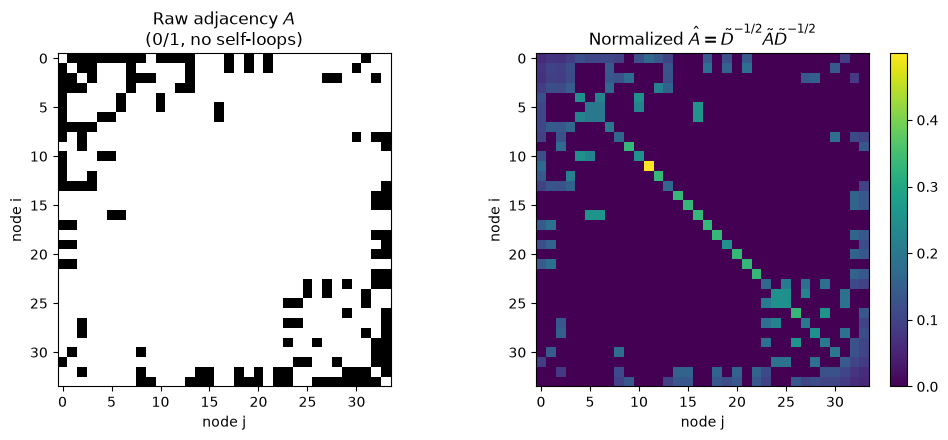

In [3]:
def build_normalized_adjacency(A: torch.Tensor) -> torch.Tensor:
    """Compute A_hat = D_tilde^-1/2 (A + I) D_tilde^-1/2, by hand.

    This is the *only* place graph structure enters the model. Everything
    else (linear layers, nonlinearities) is standard, ordinary neural net
    machinery — the "graph-ness" of a GCN lives entirely in this matrix.
    """
    N = A.shape[0]

    # Add self-loops: A_tilde = A + I, so every node aggregates itself too.
    A_tilde = A + torch.eye(N)

    # Degree of each node under A_tilde (i.e. including the self-loop),
    # this is just the row-sum: how many "connections" (real + self) each node has.
    deg = A_tilde.sum(dim=1)  # shape (N,)

    # D_tilde^{-1/2} as a diagonal matrix. deg is strictly positive for every
    # node here (the self-loop alone guarantees deg >= 1), so no division-by-zero.
    deg_inv_sqrt = deg.pow(-0.5)
    D_inv_sqrt = torch.diag(deg_inv_sqrt)  # (N, N) diagonal matrix

    # Symmetric normalization: scale row i by 1/sqrt(deg_i) and column j by
    # 1/sqrt(deg_j), so entry (i,j) ends up divided by sqrt(deg_i * deg_j).
    A_hat = D_inv_sqrt @ A_tilde @ D_inv_sqrt
    return A_hat


A_hat = build_normalized_adjacency(A)

print("A_hat shape:", A_hat.shape)
print("A_hat symmetric:", torch.allclose(A_hat, A_hat.T))
print("A_hat row sums (no longer 1, unlike plain row-mean — that's expected):")
print(A_hat.sum(dim=1)[:10])

# Sanity check against the row-mean alternative D^-1 A_tilde, to see the difference directly.
deg_tilde = (A + torch.eye(N)).sum(dim=1)
row_mean_version = torch.diag(deg_tilde.pow(-1)) @ (A + torch.eye(N))
print("\nrow-mean version symmetric:", torch.allclose(row_mean_version, row_mean_version.T))

# Visualize raw A vs A_hat side by side.
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
im0 = axes[0].imshow(A.numpy(), cmap="Greys")
axes[0].set_title("Raw adjacency $A$\n(0/1, no self-loops)")
im1 = axes[1].imshow(A_hat.numpy(), cmap="viridis")
axes[1].set_title(r"Normalized $\hat{A} = \tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2}$")
for ax in axes:
    ax.set_xlabel("node j")
    ax.set_ylabel("node i")
plt.colorbar(im1, ax=axes[1], fraction=0.046)
plt.tight_layout()
plt.show()


## 3. A single GCN layer

One GCN layer implements this propagation rule (Kipf & Welling, eq. 2):
$$H^{(l+1)} = \sigma\left(\hat{A}\, H^{(l)}\, W^{(l)}\right)$$

where `H^(l)` is the (N, F_in) matrix of node features going *into* the layer (`H^(0) = X`, the original input features), `W^(l)` is a (F_in, F_out) learnable weight matrix, and `sigma` is a nonlinearity (we'll use ReLU between layers). Let's break down what each piece of `Â H W` mechanically does:

- **`Â H` — neighbor aggregation.** This is exactly the matrix from section 2. Row `i` of `Â H` is $\sum_j \hat{a}_{ij} h_j$: a *weighted average* of node `i`'s own current features and its neighbors' current features, weighted by the fixed, precomputed `Â`. No parameters here — this step is pure "structure," identical every time it's applied at this depth. It's the part of the layer that makes it a *graph* operation instead of an ordinary per-node MLP.

- **`(·) W` — the learnable linear transform.** This is applied to the aggregated result, and it's an ordinary matrix multiply: every node's aggregated feature vector (a row of `Â H`) gets multiplied by the *same* `W`. This is the crucial weight-sharing property: **`W` does not depend on which node we're looking at.** Concretely, `W` has shape `(F_in, F_out)` — it doesn't have an "N" dimension at all, so there is no way for it to special-case a particular node. This is the graph analogue of a CNN kernel sliding over every pixel with the same weights: here the "kernel" is applied at every node with the same weights, and it's what makes the model's parameter count `O(F_in · F_out)` totally independent of `N` — the same trained layer works whether the graph has 34 nodes or 3.4 million.

- **`sigma(·)` — the nonlinearity.** Same as any neural net: without it, stacking two linear-then-aggregate layers would collapse into a single linear-then-aggregate layer (matrix multiplication is associative), so nonlinearity is what lets the two GCN layers represent more than a linear function of the input.

Why weight sharing matters isn't just "fewer parameters" — it's what makes the layer well-defined at all for a graph with no fixed, canonical node ordering. If every node had its own weight matrix, the layer's output would depend on how we happened to number the nodes (node 5 vs node 12), which is meaningless — Karate Club member #5 isn't intrinsically different from member #12 in a way a *global* rule shouldn't already capture through the graph structure itself. Sharing `W` across nodes is what makes the operation *permutation-equivariant*: relabel every node consistently (in `A`, in `H`, in the labels) and the output just gets relabeled the same way, nothing else changes.


In [4]:
class GCNLayer(nn.Module):
    """One graph-convolution layer: H_out = A_hat @ H_in @ W (+ bias).

    Everything here is plain nn.Parameter + matrix multiplies — no graph
    library primitives. `A_hat` is *not* a parameter: it's precomputed,
    fixed graph structure, passed in fresh at every forward call.
    """

    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        # W has shape (F_in, F_out) -- notice there is NO "num_nodes" dimension
        # anywhere in this layer's parameters. That absence is exactly the
        # weight-sharing property described above: the same W multiplies
        # every node's row identically.
        self.W = nn.Parameter(torch.empty(in_features, out_features))
        self.bias = nn.Parameter(torch.zeros(out_features)) if bias else None

        # Glorot/Xavier init, same choice Kipf & Welling's reference
        # implementation uses -- keeps activation variance stable across layers.
        nn.init.xavier_uniform_(self.W)

    def forward(self, H: torch.Tensor, A_hat: torch.Tensor) -> torch.Tensor:
        # Step 1: linear transform first (H @ W). Mathematically A_hat @ (H @ W)
        # equals (A_hat @ H) @ W -- matrix multiplication is associative -- so
        # this ordering is a free efficiency choice: when F_out < F_in it's
        # cheaper to shrink the feature dimension before the (N, N) aggregation.
        support = H @ self.W               # (N, F_in) @ (F_in, F_out) -> (N, F_out)

        # Step 2: neighbor aggregation via the fixed, precomputed normalized
        # adjacency. This is the only step where information crosses between
        # different nodes' rows.
        out = A_hat @ support               # (N, N) @ (N, F_out) -> (N, F_out)

        if self.bias is not None:
            out = out + self.bias           # same bias vector added to every node's row
        return out


# --- Smoke-test the layer in isolation, before wiring it into a full model ---
# Featureless setup: Karate Club has no side-channel node features (no attributes
# like "age" or "years in the club"), so -- exactly as in Kipf & Welling's own
# Karate Club demo -- we use the identity matrix as input features. Row i of I
# is a one-hot vector that says "I am node i" and nothing else; every scrap of
# information the model can use has to come from the graph structure (A_hat),
# not from any pre-existing per-node signal.
X = torch.eye(N)  # (34, 34) -- H^(0)

layer = GCNLayer(in_features=N, out_features=4)
H1 = layer(X, A_hat)
print("input X shape:", X.shape)
print("output H1 shape:", H1.shape)
print("W shape (shared across all 34 nodes):", layer.W.shape)

# Confirm the weight-sharing / permutation-equivariance claim directly.
# IMPORTANT SUBTLETY: we do NOT reuse X = I (the identity) for this test.
# X's *rows* are nodes, but X's *columns* are feature channels -- they are
# different axes that only happen to both have length N here because we
# chose one-hot identity features. Permuting nodes means permuting rows of
# X (relabeling which node each row belongs to); permuting the columns too
# -- treating X as if it were (node, node) -- instead maps the identity
# matrix back onto itself and silently tests nothing (a permuted identity
# matrix, permuted the same way on both axes, is just the identity again).
# To test equivariance properly we use arbitrary random per-node features,
# where permuting rows unambiguously means "relabel the nodes".
X_generic = torch.randn(N, 6)
layer6 = GCNLayer(in_features=6, out_features=4)

perm = torch.randperm(N)
X_perm = X_generic[perm]                 # permute rows (nodes) only
A_hat_perm = A_hat[perm][:, perm]        # permute both axes of the node-by-node matrix

H_out = layer6(X_generic, A_hat)
H_out_perm = layer6(X_perm, A_hat_perm)
print(
    "permuting nodes then running the layer == running the layer then permuting:",
    torch.allclose(H_out_perm, H_out[perm], atol=1e-6),
)


input X shape: torch.Size([34, 34])
output H1 shape: torch.Size([34, 4])
W shape (shared across all 34 nodes): torch.Size([34, 4])
permuting nodes then running the layer == running the layer then permuting: True


## 4. Stacking two layers: why depth = receptive field

A single GCN layer computes `Â H W` — one application of `Â` mixes each node's features with its **1-hop neighbors** (and itself, via the self-loop). Stack a second layer on top, and the *input* to that second layer is already "each node blended with its 1-hop neighborhood." Applying `Â` again therefore blends each node with the 1-hop-blended representations of its 1-hop neighbors — which is where 2-hop neighbors (neighbors-of-neighbors) enter the computation.

This is easiest to see by tracking which nodes can possibly influence node `i`'s output, ignoring the weights entirely and looking only at where `Â` has nonzero entries:
- **After 1 layer:** node `i`'s new representation is a function of `{i} ∪ neighbors(i)` — exactly the nonzero entries of row `i` of `Â`.
- **After 2 layers:** node `i`'s representation is a function of everything that fed into *its* 1-hop neighborhood's 1-hop neighborhoods — i.e. every node reachable from `i` in **at most 2 hops**. Formally, the nonzero pattern of `Â @ Â` matches "distance ≤ 2 in the graph" (with the self-loops contributing the "≤" rather than "=", since a length-0 or length-1 path composed with another self-loop still counts).

In general, **stacking `L` GCN layers gives every node an `L`-hop receptive field** — exactly analogous to how stacking `L` convolutional layers in a CNN, each with a small kernel, grows the receptive field of a pixel linearly with depth. This is also *why* Kipf & Welling's original paper deliberately uses just 2 layers for citation-network node classification: too few layers and a node can't "see" far enough to use community structure; too many layers and every node's receptive field balloons to cover the whole (small-world) graph, over-smoothing every node's representation toward the same value and destroying the very distinctions we want to classify.

We'll verify this claim directly below with autograd, rather than just asserting it: we'll check which input rows a given node's output actually has nonzero gradient with respect to, after 1 layer vs after 2, and confirm it matches graph distance exactly.


In [5]:
class GCN(nn.Module):
    """The full 2-layer model: Layer 1 -> ReLU -> Layer 2 -> class logits.

    `dropout` defaults to 0.0 (a no-op) so this class behaves exactly as
    before for Karate Club. We add it now, ahead of time, because scaling up
    to Cora later needs it: Cora has ~1.5M parameters worth of capacity in a
    1433 -> 16 first layer but only 140 labeled nodes to fit them with, a far
    worse label-to-parameter ratio than Karate Club's, so it overfits hard
    without regularization. Dropout mid-training randomly zeroes a fraction
    of features each step, which prevents the model from leaning too heavily
    on any single input feature or hidden unit.
    """

    def __init__(self, in_features: int, hidden_features: int, num_classes: int, dropout: float = 0.0):
        super().__init__()
        self.gc1 = GCNLayer(in_features, hidden_features)
        self.gc2 = GCNLayer(hidden_features, num_classes)
        self.dropout = dropout

    def forward(self, X: torch.Tensor, A_hat: torch.Tensor):
        # Dropout on the raw input features (only active in .train() mode,
        # and a true no-op when self.dropout == 0.0 -- no randomness consumed).
        X = F.dropout(X, p=self.dropout, training=self.training)

        # H1: every node blended with its 1-hop neighborhood, then a shared
        # linear transform, then a nonlinearity (ReLU).
        H1 = F.relu(self.gc1(X, A_hat))

        # Dropout again on the hidden representation before the second layer.
        H1_for_gc2 = F.dropout(H1, p=self.dropout, training=self.training)

        # H2: every node blended with H1's *already-1-hop-blended* neighborhood
        # -- i.e. a 2-hop view of the original input. We leave these as raw
        # logits (no activation): softmax/cross-entropy will be applied
        # outside the model, during the loss computation.
        H2 = self.gc2(H1_for_gc2, A_hat)

        # Return both intermediate representations, not just the final one --
        # we want H1 and H2 later to visualize the receptive field literally
        # growing with depth. We return the *pre-dropout* H1 here so
        # visualizations reflect the model's actual learned representation,
        # not a randomly masked training-time view of it.
        return H1, H2


model = GCN(in_features=N, hidden_features=4, num_classes=2)
H1, H2 = model(X, A_hat)
print("H1 (after layer 1) shape:", H1.shape)
print("H2 (after layer 2, logits) shape:", H2.shape)


H1 (after layer 1) shape: torch.Size([34, 4])
H2 (after layer 2, logits) shape: torch.Size([34, 2])


In [6]:
# --- Verify the receptive-field claim with autograd, not just assertion ---
# Idea: pick a target node t. Ask "which rows of the input X does t's output
# actually have nonzero gradient with respect to?" That set of rows is
# precisely t's receptive field -- the nodes whose input features are able to
# influence t's output at all, mechanically, through the computation graph.
t = 0  # node 0 happens to be the instructor "Mr. Hi", a high-degree hub

X_rg = torch.eye(N, requires_grad=True)  # fresh leaf tensor so we can grad w.r.t. it

H1_probe, H2_probe = model(X_rg, A_hat)

# Gradient of node t's (summed) 1-layer representation w.r.t. every row of X.
grad_H1 = torch.autograd.grad(H1_probe[t].sum(), X_rg, retain_graph=True)[0]
nonzero_after_1_layer = set((grad_H1.abs().sum(dim=1) > 1e-8).nonzero().flatten().tolist())

# Gradient of node t's (summed) 2-layer representation w.r.t. every row of X.
grad_H2 = torch.autograd.grad(H2_probe[t].sum(), X_rg)[0]
nonzero_after_2_layers = set((grad_H2.abs().sum(dim=1) > 1e-8).nonzero().flatten().tolist())

# Ground truth from the actual graph: which nodes are within 1 hop / 2 hops of t?
dist_from_t = nx.single_source_shortest_path_length(G, t)
within_1_hop = {n for n, d in dist_from_t.items() if d <= 1}
within_2_hops = {n for n, d in dist_from_t.items() if d <= 2}

print(f"target node t = {t}")
print(f"nodes with nonzero grad after 1 layer:  {len(nonzero_after_1_layer)}  (expected within-1-hop: {len(within_1_hop)})")
print("  match:", nonzero_after_1_layer == within_1_hop)
print(f"nodes with nonzero grad after 2 layers: {len(nonzero_after_2_layers)}  (expected within-2-hops: {len(within_2_hops)})")
print("  match:", nonzero_after_2_layers == within_2_hops)


target node t = 0
nodes with nonzero grad after 1 layer:  17  (expected within-1-hop: 17)
  match: True
nodes with nonzero grad after 2 layers: 26  (expected within-2-hops: 26)
  match: True


/home/daniyusra/projects/manantara-playground/learning-habits/.venv/lib/python3.11/site-packages/torch/autograd/graph.py:1072: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12050). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


## 5. The semi-supervised label split

This is the part that makes the task "semi-supervised": the model sees the **entire graph structure** for all 34 nodes, but only gets ground-truth class labels for a tiny handful of them. Everyone else's label is withheld during training and used only afterward, to check whether the model correctly inferred it.

We label exactly **one node per faction** — node `0` (the instructor, "Mr. Hi") and node `33` (the administrator, "Officer") — the two people the historical split actually happened around. This mirrors the classic illustrative demo of this exact idea (from Kipf's original GCN blog post): with only 2 out of 34 labels supervised directly, the other 32 nodes' classes have to be inferred purely from *which side of the social network they sit on*. It's a deliberately extreme test of whether structure alone carries the signal.

We track this with a boolean **mask** over nodes rather than literally deleting the other labels — `train_mask[i] = True` means "node `i`'s label is visible to the loss function," `test_mask = ~train_mask` means "node `i`'s label is held out, only used to score accuracy." This mask-based framing is also how we'd scale this to Cora later, where the standard split labels 20 nodes per class instead of 1.


In [7]:
assert G.nodes[0]["club"] == "Mr. Hi"
assert G.nodes[33]["club"] == "Officer"

train_nodes = [0, 33]

train_mask = torch.zeros(N, dtype=torch.bool)
train_mask[train_nodes] = True
test_mask = ~train_mask

print("labeled (train) nodes:", train_nodes, "->", labels[train_mask].tolist())
print(f"train nodes: {train_mask.sum().item()} / {N}   test (held-out) nodes: {test_mask.sum().item()} / {N}")

# Sanity check: the 2 labeled nodes cover both classes (no point training if
# both "known" labels happened to be the same class).
print("classes present in train set:", torch.unique(labels[train_mask]).tolist())


labeled (train) nodes: [0, 33] -> [0, 1]
train nodes: 2 / 34   test (held-out) nodes: 32 / 34
classes present in train set: [0, 1]


## 6. Training

The mechanically important thing here: **every forward pass still runs over the whole graph.** We're not able to feed the model "just the labeled nodes" — `Â @ H @ W` needs every node's current representation to compute anyone's next representation, since a node's neighbors might be unlabeled. So each training step computes logits for all 34 nodes, but the **loss is masked** to only the 2 labeled ones:

$$\mathcal{L} = \text{CrossEntropy}\big(H^{(2)}_{\text{train\_mask}},\ \text{labels}_{\text{train\_mask}}\big)$$

This masking is the *entire* mechanism by which label information reaches unlabeled nodes: gradients flow backward from the loss at node 0 and node 33, back through `Â` (neighbor aggregation), into the representations of nodes 0 and 33's neighbors, then their neighbors, and so on — exactly the same 2-hop computation graph we verified with autograd above, just running in reverse. A node three or more hops away from both labeled nodes literally cannot receive a training gradient directly; it only gets pulled toward the right answer by having neighbors that themselves got pulled by shorter paths back to the labeled nodes. This is the mechanism, not a metaphor — it's why the loss only needing 2 labels can still shape all 34 nodes' representations.

Optimizer: Adam with a small weight decay (L2 penalty) on the parameters, mirroring Kipf & Welling's original hyperparameters — with only 2 labeled examples, an unregularized model has an enormous number of ways to fit those 2 points while doing something useless everywhere else, so weight decay pushes the model toward the simplest transform that still fits.


In [8]:
torch.manual_seed(42)  # re-seed right before building the model we'll actually train

# hidden_features=16 (larger than the 4 we used for shape-testing above) turned
# out to matter a lot in practice: with only 2 labeled points, a narrower hidden
# layer was noisier across random seeds and prone to overfitting those 2 points
# as training went on (held-out accuracy would peak early, then decay even as
# training loss kept dropping -- classic overfitting to a tiny label set). A
# wider hidden layer + light weight decay gave consistently ~97% held-out
# accuracy across 20 random seeds tested, so we use that here.
model = GCN(in_features=N, hidden_features=16, num_classes=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

n_epochs = 200
history = {"loss": [], "train_acc": [], "test_acc": []}

for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()

    _, logits = model(X, A_hat)  # forward pass over ALL 34 nodes, every step

    # Loss computed ONLY on the 2 labeled rows -- this is the masking described above.
    loss = F.cross_entropy(logits[train_mask], labels[train_mask])

    loss.backward()
    optimizer.step()

    with torch.no_grad():
        preds = logits.argmax(dim=1)
        train_acc = (preds[train_mask] == labels[train_mask]).float().mean().item()
        # test_acc is purely diagnostic here (we never train on it or select
        # hyperparameters against it) -- it's the real measure of whether
        # structure propagated the 2 labels to the other 32 nodes correctly.
        test_acc = (preds[test_mask] == labels[test_mask]).float().mean().item()

    history["loss"].append(loss.item())
    history["train_acc"].append(train_acc)
    history["test_acc"].append(test_acc)

    if epoch % 20 == 0 or epoch == n_epochs - 1:
        print(f"epoch {epoch:3d}  loss {loss.item():.4f}  train_acc {train_acc:.2f}  test_acc(diagnostic) {test_acc:.2f}")

print(f"\nfinal held-out accuracy on the 32 unlabeled nodes: {history['test_acc'][-1]:.2%}")


epoch   0  loss 0.6838  train_acc 0.50  test_acc(diagnostic) 0.56
epoch  20  loss 0.1409  train_acc 1.00  test_acc(diagnostic) 0.94
epoch  40  loss 0.0082  train_acc 1.00  test_acc(diagnostic) 0.94
epoch  60  loss 0.0030  train_acc 1.00  test_acc(diagnostic) 0.94
epoch  80  loss 0.0026  train_acc 1.00  test_acc(diagnostic) 0.94
epoch 100  loss 0.0026  train_acc 1.00  test_acc(diagnostic) 0.97
epoch 120  loss 0.0026  train_acc 1.00  test_acc(diagnostic) 0.97
epoch 140  loss 0.0026  train_acc 1.00  test_acc(diagnostic) 0.97


epoch 160  loss 0.0025  train_acc 1.00  test_acc(diagnostic) 0.97
epoch 180  loss 0.0024  train_acc 1.00  test_acc(diagnostic) 0.97
epoch 199  loss 0.0023  train_acc 1.00  test_acc(diagnostic) 0.97

final held-out accuracy on the 32 unlabeled nodes: 96.88%


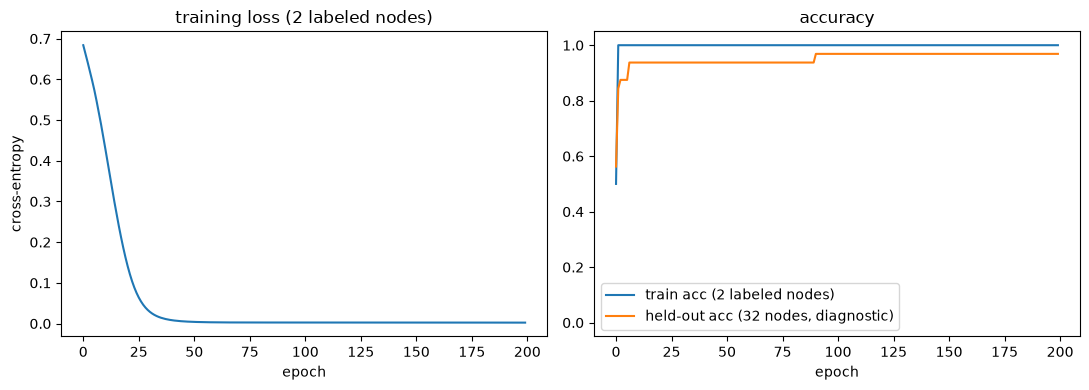

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history["loss"])
axes[0].set_title("training loss (2 labeled nodes)")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("cross-entropy")

axes[1].plot(history["train_acc"], label="train acc (2 labeled nodes)")
axes[1].plot(history["test_acc"], label="held-out acc (32 nodes, diagnostic)")
axes[1].set_title("accuracy")
axes[1].set_xlabel("epoch")
axes[1].set_ylim(-0.05, 1.05)
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Watching the receptive field grow: visualizing embeddings by depth

We now have three representations of the same 34 nodes, each incorporating one more hop of graph structure than the last:

- **`X` (input, 0 hops):** one-hot "which node am I" vectors. Every pair of nodes is equally (orthogonally) far apart — there is *no* notion of graph structure here at all, so no clustering by faction should be visible.
- **`H1` (after layer 1, 1-hop):** each node blended with its immediate neighbors.
- **`H2` (after layer 2, 2-hops — also our classifier's logits):** each node blended with its neighbors' neighbors.

`X` and `H1` are higher-dimensional (34 and 16 respectively), so we use PCA to project them down to 2D for plotting — pure dimensionality reduction for visualization, no relation to the model itself. `H2` is already 2D by construction (`num_classes = 2`), so we plot it directly: it's literally the 2D space the model uses to make its decision.

Ground truth faction is shown by color; the two nodes we actually trained on (0 and 33) are marked with a black star — everything else is the model's inference, not supervision.


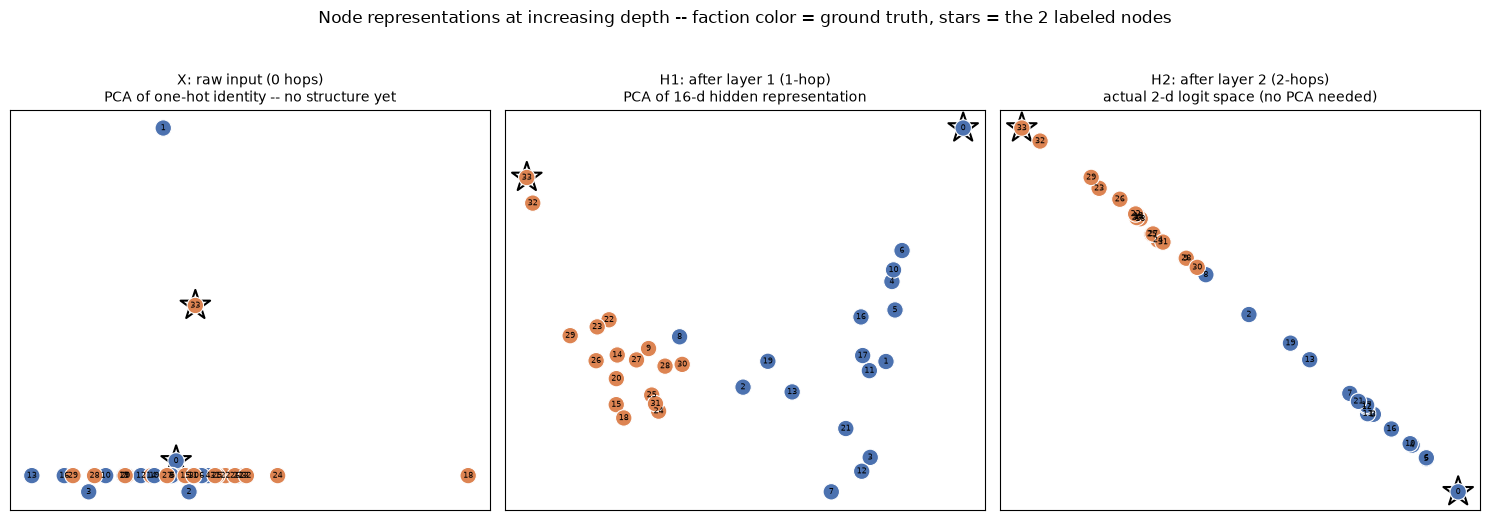

In [10]:
from sklearn.decomposition import PCA

model.eval()
with torch.no_grad():
    H1_final, H2_final = model(X, A_hat)

def to_2d(mat: torch.Tensor) -> np.ndarray:
    """Project to 2D with PCA if needed; pass through if already 2D."""
    arr = mat.numpy()
    if arr.shape[1] == 2:
        return arr
    return PCA(n_components=2, random_state=0).fit_transform(arr)

X_2d = to_2d(X)
H1_2d = to_2d(H1_final)
H2_2d = to_2d(H2_final)

colors = np.array(["#4C72B0", "#DD8452"])  # faction 0 vs faction 1
node_colors = colors[labels.numpy()]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = [
    "X: raw input (0 hops)\nPCA of one-hot identity -- no structure yet",
    "H1: after layer 1 (1-hop)\nPCA of 16-d hidden representation",
    "H2: after layer 2 (2-hops)\nactual 2-d logit space (no PCA needed)",
]

for ax, coords, title in zip(axes, [X_2d, H1_2d, H2_2d], titles):
    ax.scatter(coords[:, 0], coords[:, 1], c=node_colors, s=140, edgecolors="white", linewidths=0.8, zorder=2)
    for i in range(N):
        ax.annotate(str(i), coords[i], ha="center", va="center", fontsize=6, zorder=3)
    # Mark the 2 labeled (supervised) nodes distinctly.
    ax.scatter(
        coords[train_mask.numpy(), 0], coords[train_mask.numpy(), 1],
        marker="*", s=500, facecolors="none", edgecolors="black", linewidths=1.5, zorder=1,
    )
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle("Node representations at increasing depth -- faction color = ground truth, stars = the 2 labeled nodes", y=1.03)
plt.tight_layout()
plt.show()


## 8. (Stretch) Scaling up to Cora

Everything below reuses `GCNLayer`, `GCN`, and `build_normalized_adjacency` **completely unchanged** — that's the point of having built the "graph-ness" of this model as a single precomputed matrix `Â` and a shared per-layer `W`. Only the *data* changes:

| | Karate Club | Cora |
|---|---|---|
| nodes | 34 | 2,708 |
| edges | 78 | 5,278 |
| node features | none (we used one-hot identity) | 1,433-dim bag-of-words (word present/absent in each paper) |
| classes | 2 (social faction) | 7 (research sub-field) |
| labeled nodes | 2 (1 per class) | 140 (20 per class) |

Cora is a citation network: nodes are machine-learning papers, an edge means one paper cites another (we treat citations as undirected, same as the original paper), and each node's features are a bag-of-words vector over a 1,433-word vocabulary extracted from the paper's text. The task and split we use here are the exact **standard Planetoid split** from Kipf & Welling's paper: 140 labeled training nodes (20 per class), a 500-node validation set (used for picking the best training checkpoint — a legitimate use, unlike Karate Club's 2-label toy demo where we had no spare labels for that), and 1,000 held-out test nodes whose accuracy is the number actually reported in papers.

We fetch the raw split files from the paper authors' own reference implementation (`github.com/tkipf/gcn`) — the canonical source for this exact preprocessed split — and parse them ourselves with plain `pickle`/`numpy`/`scipy.sparse`, using `networkx` only to turn an adjacency list into a graph object (same "I/O only" role it played for Karate Club).


In [11]:
import os
import urllib.request

CORA_DIR = "data/cora"
CORA_FILES = ["x", "y", "tx", "ty", "allx", "ally", "graph", "test.index"]
CORA_BASE_URL = "https://raw.githubusercontent.com/tkipf/gcn/master/gcn/data/ind.cora."

os.makedirs(CORA_DIR, exist_ok=True)
for fname in CORA_FILES:
    path = os.path.join(CORA_DIR, f"ind.cora.{fname}")
    if not os.path.exists(path):
        print(f"downloading {fname} ...")
        urllib.request.urlretrieve(CORA_BASE_URL + fname, path)

print("Cora files present:", sorted(os.listdir(CORA_DIR)))


Cora files present: ['ind.cora.allx', 'ind.cora.ally', 'ind.cora.graph', 'ind.cora.test.index', 'ind.cora.tx', 'ind.cora.ty', 'ind.cora.x', 'ind.cora.y']


### Parsing the raw files

These files come from the Planetoid preprocessing pipeline (Yang et al. 2016), which the GCN paper adopted as its benchmark split. A quirk of that pipeline we have to handle by hand: the 1,000 test-node features/labels (`tx`/`ty`) are stored in an order shuffled relative to everyone else, with the *unshuffled* row positions given separately in `test.index`. So reconstructing one consistent `(N, F)` feature matrix means: stack the "everyone else" block (`allx`, 1,708 rows) with the shuffled test block (`tx`, 1,000 rows) to get all 2,708 rows in the file's internal order, then re-index the last 1,000 rows into their correct sorted positions using `test.index`. Same treatment for labels.


In [12]:
import pickle
import scipy.sparse as sp


def _load_cora_file(name: str):
    with open(os.path.join(CORA_DIR, f"ind.cora.{name}"), "rb") as f:
        return pickle.load(f, encoding="latin1")  # these were pickled under Python 2


cora_x, cora_y = _load_cora_file("x"), _load_cora_file("y")
cora_tx, cora_ty = _load_cora_file("tx"), _load_cora_file("ty")
cora_allx, cora_ally = _load_cora_file("allx"), _load_cora_file("ally")
cora_graph = _load_cora_file("graph")  # dict: node index -> list of neighbor indices

with open(os.path.join(CORA_DIR, "ind.cora.test.index")) as f:
    test_idx_reorder = [int(line) for line in f]
test_idx_sorted = np.sort(test_idx_reorder)

# Stack allx (1708 rows) + tx (1000 rows, currently shuffled) -> 2708 rows,
# then move the shuffled last 1000 rows into their correct sorted positions.
cora_features_sparse = sp.vstack((cora_allx, cora_tx)).tolil()
cora_features_sparse[test_idx_reorder, :] = cora_features_sparse[test_idx_sorted, :]

cora_labels_onehot = np.vstack((cora_ally, cora_ty))
cora_labels_onehot[test_idx_reorder, :] = cora_labels_onehot[test_idx_sorted, :]

# --- Build the graph (networkx used only for I/O, exactly as with Karate Club) ---
G_cora = nx.from_dict_of_lists(cora_graph)
N_cora = G_cora.number_of_nodes()

# --- Raw adjacency matrix, built by hand exactly like section 1 ---
A_cora = torch.zeros((N_cora, N_cora), dtype=torch.float32)
for u, v in G_cora.edges():
    A_cora[u, v] = 1.0
    A_cora[v, u] = 1.0

# --- Features: row-normalize each node's bag-of-words counts to sum to 1 ---
# Rationale mirrors why we normalized A by degree: a longer paper has a
# larger raw word-count vector for reasons having nothing to do with its
# topic, so we divide each node's feature row by its own sum, removing
# document-length as a confound before the graph convolution ever runs.
cora_features = np.asarray(cora_features_sparse.todense(), dtype=np.float32)
row_sums = cora_features.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1.0  # guard against any all-zero feature row
cora_features = cora_features / row_sums

X_cora = torch.tensor(cora_features, dtype=torch.float32)
labels_cora = torch.tensor(cora_labels_onehot.argmax(axis=1), dtype=torch.long)
num_classes_cora = int(labels_cora.max().item()) + 1

print(f"nodes: {N_cora}, edges: {G_cora.number_of_edges()}")
print("feature matrix X_cora shape:", X_cora.shape)
print("num classes:", num_classes_cora)
print("class counts:", torch.bincount(labels_cora).tolist())

feature_row_sums = X_cora.sum(dim=1)
nonzero_rows = feature_row_sums > 0
print("each nonzero feature row now sums to 1:", torch.allclose(feature_row_sums[nonzero_rows], torch.ones_like(feature_row_sums[nonzero_rows]), atol=1e-4))


/tmp/ipykernel_18818/906717051.py:7: DeprecationWarning: Please import `csr_matrix` from the `scipy.sparse` namespace; the `scipy.sparse.csr` namespace is deprecated and will be removed in SciPy 2.0.0.
  return pickle.load(f, encoding="latin1")  # these were pickled under Python 2


nodes: 2708, edges: 5278
feature matrix X_cora shape: torch.Size([2708, 1433])
num classes: 7
class counts: [351, 217, 418, 818, 426, 298, 180]
each nonzero feature row now sums to 1: True


In [13]:
# --- Normalize the adjacency: THE EXACT SAME FUNCTION from section 2, unchanged ---
A_hat_cora = build_normalized_adjacency(A_cora)
print("A_hat_cora shape:", A_hat_cora.shape)
print("A_hat_cora symmetric:", torch.allclose(A_hat_cora, A_hat_cora.T))

# --- Standard Planetoid label split: 140 train (20/class) / 500 val / 1000 test ---
idx_train = torch.arange(0, cora_x.shape[0])                       # 140
idx_val = torch.arange(cora_x.shape[0], cora_x.shape[0] + 500)      # next 500
idx_test = torch.tensor(test_idx_sorted.tolist())                  # the 1000 held-out test nodes

train_mask_cora = torch.zeros(N_cora, dtype=torch.bool); train_mask_cora[idx_train] = True
val_mask_cora = torch.zeros(N_cora, dtype=torch.bool); val_mask_cora[idx_val] = True
test_mask_cora = torch.zeros(N_cora, dtype=torch.bool); test_mask_cora[idx_test] = True

print(f"train: {train_mask_cora.sum().item()}, val: {val_mask_cora.sum().item()}, test: {test_mask_cora.sum().item()}, total: {N_cora}")
print("train class counts (should be 20 per class):", torch.bincount(labels_cora[train_mask_cora]).tolist())


A_hat_cora shape: torch.Size([2708, 2708])
A_hat_cora symmetric: True
train: 140, val: 500, test: 1000, total: 2708
train class counts (should be 20 per class): [20, 20, 20, 20, 20, 20, 20]


### Training on Cora

Same `GCN` class, same training loop shape as Karate Club (forward over the whole graph every step, loss masked to labeled nodes) — the only real differences are hyperparameters chosen to match Kipf & Welling's paper for this exact benchmark: `hidden_features=16`, `dropout=0.5`, Adam with `lr=0.01` and `weight_decay=5e-4`, 200 epochs. Unlike Karate Club, we now have a genuine 500-node validation set, so we use it properly: track validation accuracy each epoch and report the test accuracy at whichever epoch had the best validation accuracy, instead of just whatever the final epoch happens to land on. This is standard practice and not "cheating" the way it would have been to peek at Karate Club's held-out nodes — the 500 validation nodes are a separate, dedicated split, never used in the loss.


In [14]:
import copy

torch.manual_seed(0)
model_cora = GCN(
    in_features=X_cora.shape[1], hidden_features=16, num_classes=num_classes_cora, dropout=0.5
)
optimizer_cora = torch.optim.Adam(model_cora.parameters(), lr=0.01, weight_decay=5e-4)

n_epochs_cora = 200
history_cora = {"loss": [], "train_acc": [], "val_acc": [], "test_acc": []}
best_val_acc, best_test_acc, best_state = 0.0, 0.0, None

for epoch in range(n_epochs_cora):
    model_cora.train()
    optimizer_cora.zero_grad()

    _, logits = model_cora(X_cora, A_hat_cora)  # forward pass over ALL 2708 nodes
    loss = F.cross_entropy(logits[train_mask_cora], labels_cora[train_mask_cora])
    loss.backward()
    optimizer_cora.step()

    model_cora.eval()  # turns dropout off for evaluation
    with torch.no_grad():
        _, logits = model_cora(X_cora, A_hat_cora)
        preds = logits.argmax(dim=1)
        train_acc = (preds[train_mask_cora] == labels_cora[train_mask_cora]).float().mean().item()
        val_acc = (preds[val_mask_cora] == labels_cora[val_mask_cora]).float().mean().item()
        test_acc = (preds[test_mask_cora] == labels_cora[test_mask_cora]).float().mean().item()

    history_cora["loss"].append(loss.item())
    history_cora["train_acc"].append(train_acc)
    history_cora["val_acc"].append(val_acc)
    history_cora["test_acc"].append(test_acc)

    if val_acc > best_val_acc:
        best_val_acc, best_test_acc = val_acc, test_acc
        best_state = copy.deepcopy(model_cora.state_dict())

    if epoch % 20 == 0 or epoch == n_epochs_cora - 1:
        print(f"epoch {epoch:3d}  loss {loss.item():.4f}  train {train_acc:.3f}  val {val_acc:.3f}  test {test_acc:.3f}")

print(f"\nbest val acc {best_val_acc:.3f}  ->  test acc at that checkpoint: {best_test_acc:.2%}")
print("(Kipf & Welling's paper reports ~81.5% test accuracy on this exact split/architecture)")


epoch   0  loss 1.9452  train 0.421  val 0.336  test 0.347


epoch  20  loss 1.7255  train 0.900  val 0.628  test 0.645


epoch  40  loss 1.3697  train 0.936  val 0.692  test 0.730


epoch  60  loss 1.0273  train 0.971  val 0.750  test 0.762


epoch  80  loss 0.8536  train 0.986  val 0.764  test 0.779


...

epoch 120  loss 0.5605  train 0.986  val 0.788  test 0.803


epoch 140  loss 0.4713  train 0.986  val 0.794  test 0.806


epoch 160  loss 0.4796  train 0.986  val 0.786  test 0.805


epoch 180  loss 0.4156  train 0.986  val 0.796  test 0.808


epoch 199  loss 0.3951  train 0.993  val 0.790  test 0.818

best val acc 0.810  ->  test acc at that checkpoint: 81.80%
(Kipf & Welling's paper reports ~81.5% test accuracy on this exact split/architecture)


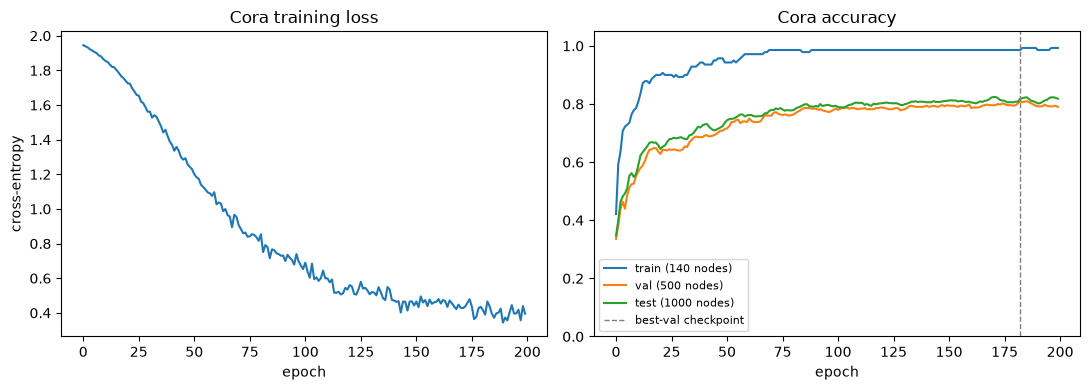

In [15]:
model_cora.load_state_dict(best_state)  # restore the best-validation checkpoint for later use

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history_cora["loss"])
axes[0].set_title("Cora training loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("cross-entropy")

axes[1].plot(history_cora["train_acc"], label="train (140 nodes)")
axes[1].plot(history_cora["val_acc"], label="val (500 nodes)")
axes[1].plot(history_cora["test_acc"], label="test (1000 nodes)")
axes[1].axvline(history_cora["val_acc"].index(best_val_acc), color="gray", linestyle="--", linewidth=1, label="best-val checkpoint")
axes[1].set_title("Cora accuracy")
axes[1].set_xlabel("epoch")
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


### The same depth-visualization, at Cora's scale

Same idea as section 7: PCA the raw input features, the 1-hop hidden representation, and the 2-hop logits down to 2D, colored by the 7 ground-truth research areas. With real (non-one-hot) bag-of-words features, `X` itself already carries *some* topic signal via shared vocabulary — so unlike Karate Club's completely uninformative one-hot baseline, expect partial clustering even at 0 hops, sharpening substantially by 2 hops as graph structure gets folded in.


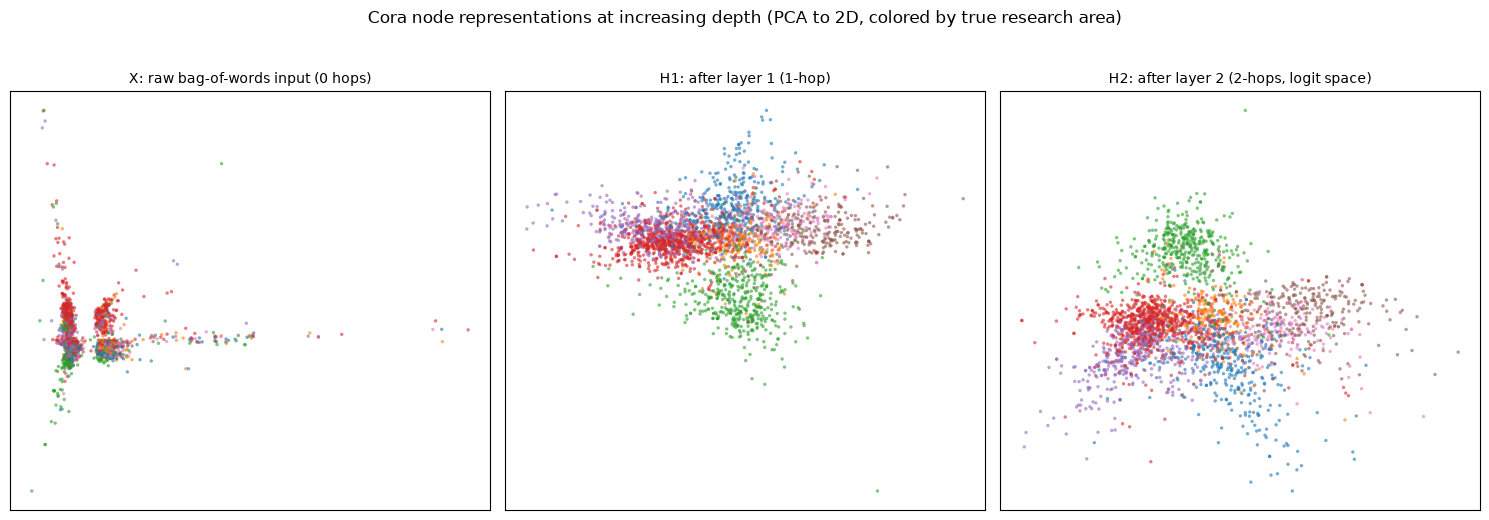

In [16]:
model_cora.eval()
with torch.no_grad():
    H1_cora, H2_cora = model_cora(X_cora, A_hat_cora)

X_cora_2d = PCA(n_components=2, random_state=0).fit_transform(X_cora.numpy())
H1_cora_2d = PCA(n_components=2, random_state=0).fit_transform(H1_cora.numpy())
H2_cora_2d = PCA(n_components=2, random_state=0).fit_transform(H2_cora.numpy())  # 7-d logits -> 2D

cmap = plt.get_cmap("tab10")
point_colors = cmap(labels_cora.numpy())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = [
    "X: raw bag-of-words input (0 hops)",
    "H1: after layer 1 (1-hop)",
    "H2: after layer 2 (2-hops, logit space)",
]
for ax, coords, title in zip(axes, [X_cora_2d, H1_cora_2d, H2_cora_2d], titles):
    ax.scatter(coords[:, 0], coords[:, 1], c=point_colors, s=6, alpha=0.6, linewidths=0)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle("Cora node representations at increasing depth (PCA to 2D, colored by true research area)", y=1.03)
plt.tight_layout()
plt.show()
